In [24]:
from scipy.io import loadmat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

def extract_soh_curve(mat_file_path):
    data = loadmat(mat_file_path)
    data_cell = data['data_cell']
    num_cycles = data_cell.shape[1]
    capacities = []
    for i in range(num_cycles):
        cycle = data_cell[0, i]
        fields = cycle.dtype.names
        # Group 1 style
        if 'dischg_Capacity_mAh' in fields:
            dischg_capacity = cycle['dischg_Capacity_mAh'][0,0]
        # Group 2/3/4 style
        elif 'dischg_Capacity_Ah' in fields:
            dischg_capacity = cycle['dischg_Capacity_Ah'][0,0]
            # convert Ah → mAh
            dischg_capacity = dischg_capacity * 1000
        else:
            continue
        final_capacity = dischg_capacity[-1,0]
        capacities.append(final_capacity)
    capacities = np.array(capacities)
    capacities = capacities[~np.isnan(capacities)]
    reference_capacity = np.max(capacities)
    soh = capacities / reference_capacity
    return soh


In [2]:
data = loadmat("../data/raw/Group 1/G1_Cell1_Data.mat")

In [3]:
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'data_cell'])


In [4]:
print(type(data['data_cell']))
print(data['data_cell'].shape)

<class 'numpy.ndarray'>
(1, 612)


In [5]:
cycle1 = data['data_cell'][0,0]

In [6]:
print(type(cycle1))
print(cycle1.dtype)

<class 'numpy.ndarray'>
[('chg_Time_s', 'O'), ('chg_Voltage_V', 'O'), ('chg_Current_mA', 'O'), ('chg_Capacity_mAh', 'O'), ('chg_StepID', 'O'), ('dischg_Time_s', 'O'), ('dischg_Voltage_V', 'O'), ('dischg_Current_mA', 'O'), ('dischg_Capacity_mAh', 'O'), ('dischg_StepID', 'O'), ('fullCycle_Time_s', 'O'), ('fullCycle_Voltage_V', 'O'), ('fullCycle_Current_mA', 'O'), ('fullCycle_StepID', 'O'), ('fullCycle_SoC', 'O')]


In [7]:
chg_voltage = cycle1['chg_Voltage_V'][0,0]
chg_time = cycle1['chg_Time_s'][0,0]
print(chg_voltage.shape)
print(chg_time.shape)

(642, 1)
(642, 1)


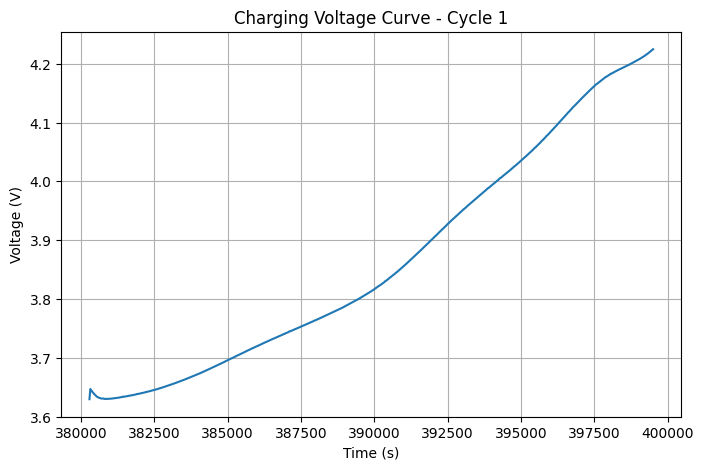

In [8]:
plt.figure(figsize=(8,5))
plt.plot(chg_time, chg_voltage)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Charging Voltage Curve - Cycle 1")
plt.grid(True)
plt.show()

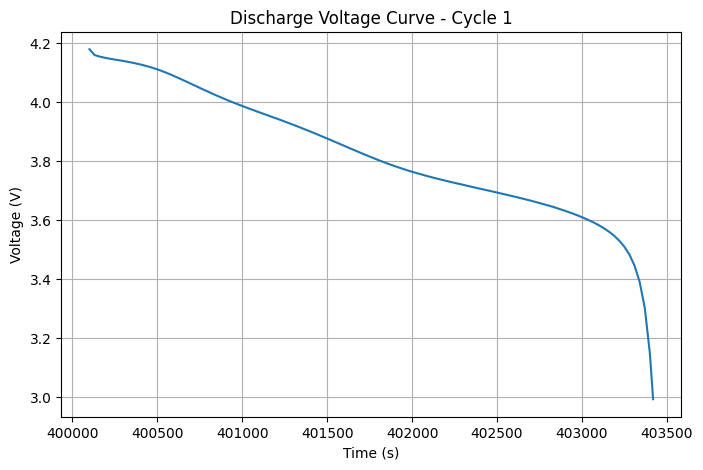

In [9]:
dischg_voltage = cycle1['dischg_Voltage_V'][0,0]
dischg_time = cycle1['dischg_Time_s'][0,0]

plt.figure(figsize=(8,5))

plt.plot(dischg_time, dischg_voltage)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Discharge Voltage Curve - Cycle 1")

plt.grid(True)
plt.show()

In [10]:
dischg_capacity = cycle1['dischg_Capacity_mAh'][0,0]
chg_capacity = cycle1['chg_Capacity_mAh'][0,0]

print(dischg_capacity.shape)
print(chg_capacity.shape)

print(dischg_capacity[:5])

(112, 1)
(642, 1)
[[-0.        ]
 [ 0.03118333]
 [ 0.06236667]
 [ 0.09355   ]
 [ 0.12473333]]


In [11]:
final_capacity = dischg_capacity[-1,0]
print("Final discharge capacity:",final_capacity,"mAh")

Final discharge capacity: 3.4502661111111292 mAh


In [12]:
num_cycles = data['data_cell'].shape[1]
capacities = []
for i in range(num_cycles):
    cycle = data['data_cell'][0,i]
    dischg_capacity = cycle['dischg_Capacity_mAh'][0,0]
    final_capacity = dischg_capacity[-1,0]
    capacities.append(final_capacity)
print("Number of cycles:",len(capacities))
print("First 5 capacities:")
print(capacities[:5]) 

Number of cycles: 612
First 5 capacities:
[np.float64(3.4502661111111292), np.float64(3.706767499999983), np.float64(3.8396233333333396), np.float64(3.782258055555597), np.float64(3.72737666666658)]


In [13]:
cycles = np.arrange(1,num_cycles + 1)
plt.figure(figsize=(10,5))
plt.plot(cycles,capacities)
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (mAh)")
plt.title("Battery Capacity Degradation")
plt.grid(True)
plt.show()

AttributeError: module 'numpy' has no attribute 'arrange'

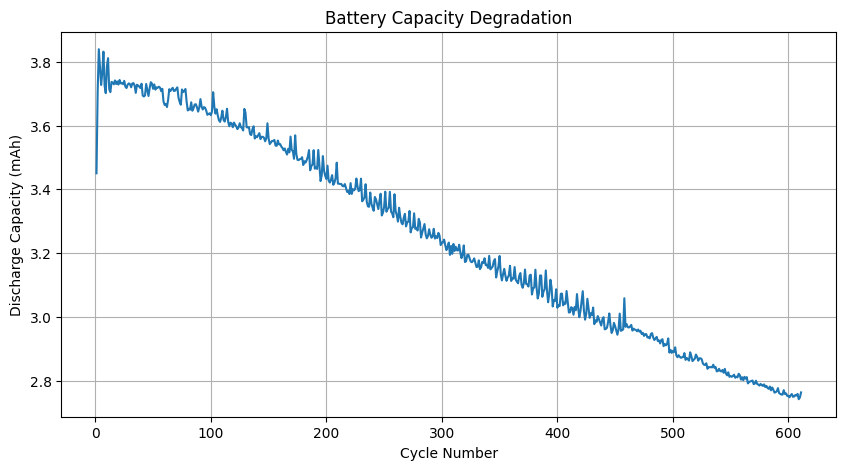

In [14]:
cycles = np.arange(1, num_cycles + 1)
plt.figure(figsize=(10,5))
plt.plot(cycles, capacities)
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (mAh)")
plt.title("Battery Capacity Degradation")
plt.grid(True)
plt.show()

In [15]:
initial_capacity = capacities[0]

soh = np.array(capacities) / initial_capacity

print("First 5 SOH values:")
print(soh[:5])

First 5 SOH values:
[1.         1.07434249 1.11284846 1.09622213 1.08031571]


In [16]:
reference_capacity = max(capacities)

soh = np.array(capacities) / reference_capacity

print("Reference capacity:", reference_capacity)

print("First 5 SOH values:")
print(soh[:5])

Reference capacity: 3.8396233333333396
First 5 SOH values:
[0.89859494 0.96539873 1.         0.98505966 0.97076623]


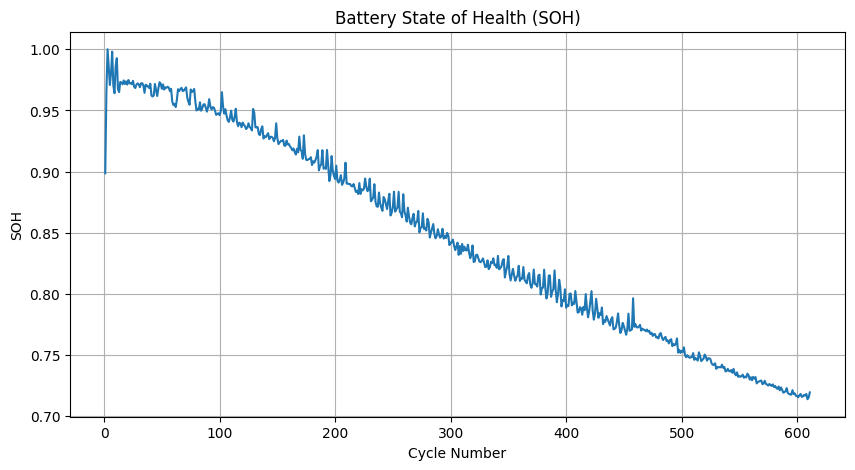

In [17]:
plt.figure(figsize=(10,5))

plt.plot(cycles, soh)

plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("Battery State of Health (SOH)")

plt.grid(True)
plt.show()

In [3]:
capacities = extract_capacity_curve(
    "../data/raw/Group 1/G1_Cell1_Data.mat"
)
print(capacities[:5])
print("Total cycles:", len(capacities))

[3.45026611 3.7067675  3.83962333 3.78225806 3.72737667]
Total cycles: 612


In [7]:
soh = extract_soh_curve(
    "../data/raw/Group 1/G1_Cell1_Data.mat"
)
print(soh[:5])
print("Total Cycles:",len(soh))

[nan nan nan nan nan]
Total Cycles: 612


In [8]:
print(np.isnan(capacities).sum())

1


In [9]:
print(capacities[:20])

[3.45026611 3.7067675  3.83962333 3.78225806 3.72737667 3.76534889
 3.83196722 3.72557361 3.70173806 3.78600694 3.81159167 3.7147625
 3.70492389 3.73690417 3.73504028 3.72946194 3.74163194 3.73046042
 3.73856306 3.72864444]


In [11]:
soh =  extract_soh_curve(
    "../data/raw/Group 1/G1_Cell1_Data.mat"
)
print(soh[:5])
print("Total cycles:",len(soh))

[0.89859494 0.96539873 1.         0.98505966 0.97076623]
Total cycles: 611


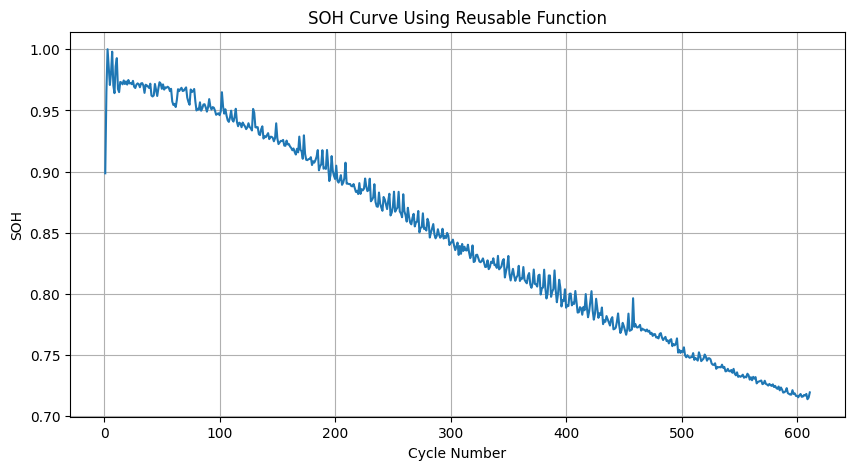

In [13]:
soh = extract_soh_curve(
    "../data/raw/Group 1/G1_Cell1_Data.mat"
)

cycles = np.arange(1, len(soh) + 1)

plt.figure(figsize=(10,5))

plt.plot(cycles, soh)

plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("SOH Curve Using Reusable Function")

plt.grid(True)
plt.show()

In [15]:
group1_files = glob.glob("../data/raw/Group 1/*Data.mat")
print("Number of files:",len(group1_files))
print("\nFIles found:")
for file in group1_files:
    print(file)


Number of files: 6

FIles found:
../data/raw/Group 1\G1_Cell1_Data.mat
../data/raw/Group 1\G1_Cell2_Data.mat
../data/raw/Group 1\G1_Cell3_Data.mat
../data/raw/Group 1\G1_Cell4_Data.mat
../data/raw/Group 1\G1_Cell5_Data.mat
../data/raw/Group 1\G1_Cell6_Data.mat


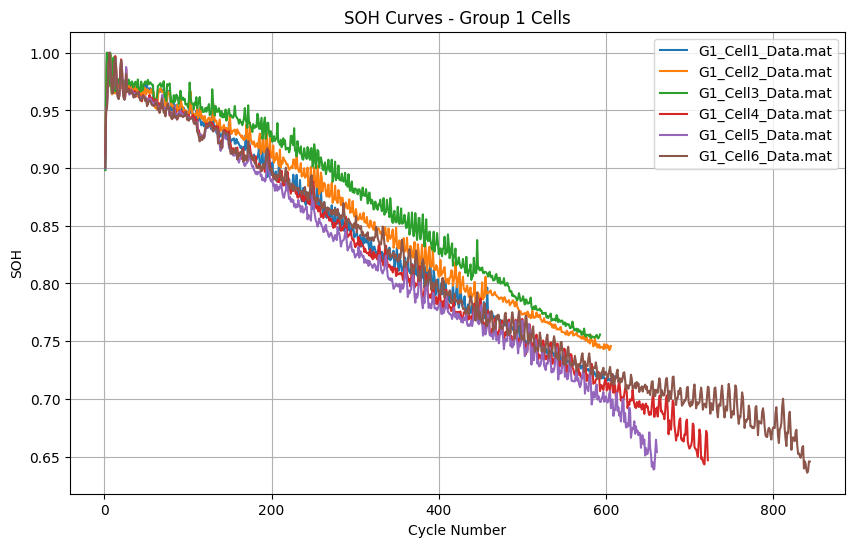

In [16]:
plt.figure(figsize=(10,6))
for file in group1_files:
    soh = extract_soh_curve(file)
    cycles = np.arange(1, len(soh) + 1)
    file_name = file.split("\\")[-1]
    plt.plot(cycles, soh, label=file_name)

plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("SOH Curves - Group 1 Cells")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
all_data = []

In [18]:
for file in group1_files:
    soh = extract_soh_curve(file)
    file_name = file.split("\\")[-1]
    cell_name = file_name.replace("_Data.mat","")
    for cycle_num, soh_value in enumerate(soh, start=1):
        all_data.append({
            "group" : 1,
            "cell": cell_name,
            "cycle":cycle_num,
            "soh":soh_value
        })

In [19]:
df = pd.DataFrame(all_data)
df.head()

,group,cell,cycle,soh
0,1,G1_Cell1,1,0.898595
1,1,G1_Cell1,2,0.965399
2,1,G1_Cell1,3,1.000000
3,1,G1_Cell1,4,0.985060
4,1,G1_Cell1,5,0.970766


In [20]:
all_data = []

for group_num in range(1, 5):

    pattern = f"../data/raw/Group {group_num}/*Data.mat"

    group_files = glob.glob(pattern)

    print(f"Group {group_num}: {len(group_files)} files")

    for file in group_files:

        soh = extract_soh_curve(file)

        file_name = file.split("\\")[-1]

        cell_name = file_name.replace("_Data.mat", "")

        for cycle_num, soh_value in enumerate(soh, start=1):

            all_data.append({
                "group": group_num,
                "cell": cell_name,
                "cycle": cycle_num,
                "soh": soh_value
            })

Group 1: 6 files
Group 2: 5 files


ValueError: no field of name dischg_Capacity_mAh

In [21]:
all_data = []

for group_num in range(1, 5):

    pattern = f"../data/raw/Group {group_num}/*Data.mat"

    group_files = glob.glob(pattern)

    print(f"\nGroup {group_num}: {len(group_files)} files")

    for file in group_files:

        print("Processing:", file)

        soh = extract_soh_curve(file)


Group 1: 6 files
Processing: ../data/raw/Group 1\G1_Cell1_Data.mat
Processing: ../data/raw/Group 1\G1_Cell2_Data.mat
Processing: ../data/raw/Group 1\G1_Cell3_Data.mat
Processing: ../data/raw/Group 1\G1_Cell4_Data.mat
Processing: ../data/raw/Group 1\G1_Cell5_Data.mat
Processing: ../data/raw/Group 1\G1_Cell6_Data.mat

Group 2: 5 files
Processing: ../data/raw/Group 2\G2_Cell1_Data.mat


ValueError: no field of name dischg_Capacity_mAh

In [22]:
g2_data = loadmat("../data/raw/Group 2/G2_Cell1_Data.mat")

print(g2_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'data_cell'])


In [23]:
g2_cycle1 = g2_data['data_cell'][0,0]

print(g2_cycle1.dtype)

[('chg_Time_s', 'O'), ('chg_Voltage_V', 'O'), ('chg_Current_A', 'O'), ('chg_Capacity_Ah', 'O'), ('chg_StepID', 'O'), ('dischg_Time_s', 'O'), ('dischg_Voltage_V', 'O'), ('dischg_Current_A', 'O'), ('dischg_Capacity_Ah', 'O'), ('dischg_StepID', 'O'), ('fullCycle_Time_s', 'O'), ('fullCycle_Voltage_V', 'O'), ('fullCycle_Current_A', 'O'), ('fullCycle_StepID', 'O'), ('fullCycle_SoC', 'O')]


In [25]:
soh = extract_soh_curve(
    "../data/raw/Group 2/G2_Cell1_Data.mat"
)

print(soh[:5])
print(len(soh))

[0.95410604 0.94427329 0.90894827 0.89200956 0.97747764]
528


In [26]:
all_data = []

for group_num in range(1, 5):

    pattern = f"../data/raw/Group {group_num}/*Data.mat"

    group_files = glob.glob(pattern)

    print(f"\nGroup {group_num}: {len(group_files)} files")

    for file in group_files:

        print("Processing:", file)

        soh = extract_soh_curve(file)

        file_name = file.split("\\")[-1]

        cell_name = file_name.replace("_Data.mat", "")

        for cycle_num, soh_value in enumerate(soh, start=1):

            all_data.append({
                "group": group_num,
                "cell": cell_name,
                "cycle": cycle_num,
                "soh": soh_value
            })


Group 1: 6 files
Processing: ../data/raw/Group 1\G1_Cell1_Data.mat
Processing: ../data/raw/Group 1\G1_Cell2_Data.mat
Processing: ../data/raw/Group 1\G1_Cell3_Data.mat
Processing: ../data/raw/Group 1\G1_Cell4_Data.mat
Processing: ../data/raw/Group 1\G1_Cell5_Data.mat
Processing: ../data/raw/Group 1\G1_Cell6_Data.mat

Group 2: 5 files
Processing: ../data/raw/Group 2\G2_Cell1_Data.mat
Processing: ../data/raw/Group 2\G2_Cell2_Data.mat
Processing: ../data/raw/Group 2\G2_Cell3_Data.mat
Processing: ../data/raw/Group 2\G2_Cell4_Data.mat
Processing: ../data/raw/Group 2\G2_Cell5_Data.mat

Group 3: 7 files
Processing: ../data/raw/Group 3\G3_Cell1_Data.mat
Processing: ../data/raw/Group 3\G3_Cell2_Data.mat
Processing: ../data/raw/Group 3\G3_Cell3_Data.mat
Processing: ../data/raw/Group 3\G3_Cell4_Data.mat
Processing: ../data/raw/Group 3\G3_Cell5_Data.mat
Processing: ../data/raw/Group 3\G3_Cell6_Data.mat
Processing: ../data/raw/Group 3\G3_Cell7_Data.mat

Group 4: 5 files
Processing: ../data/raw/Grou

In [27]:
df = pd.DataFrame(all_data)

print(df.shape)

df.head()


(11005, 4)


,group,cell,cycle,soh
0,1,G1_Cell1,1,0.898595
1,1,G1_Cell1,2,0.965399
2,1,G1_Cell1,3,1.000000
3,1,G1_Cell1,4,0.985060
4,1,G1_Cell1,5,0.970766


In [28]:
print(df.shape)

(11005, 4)
